Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


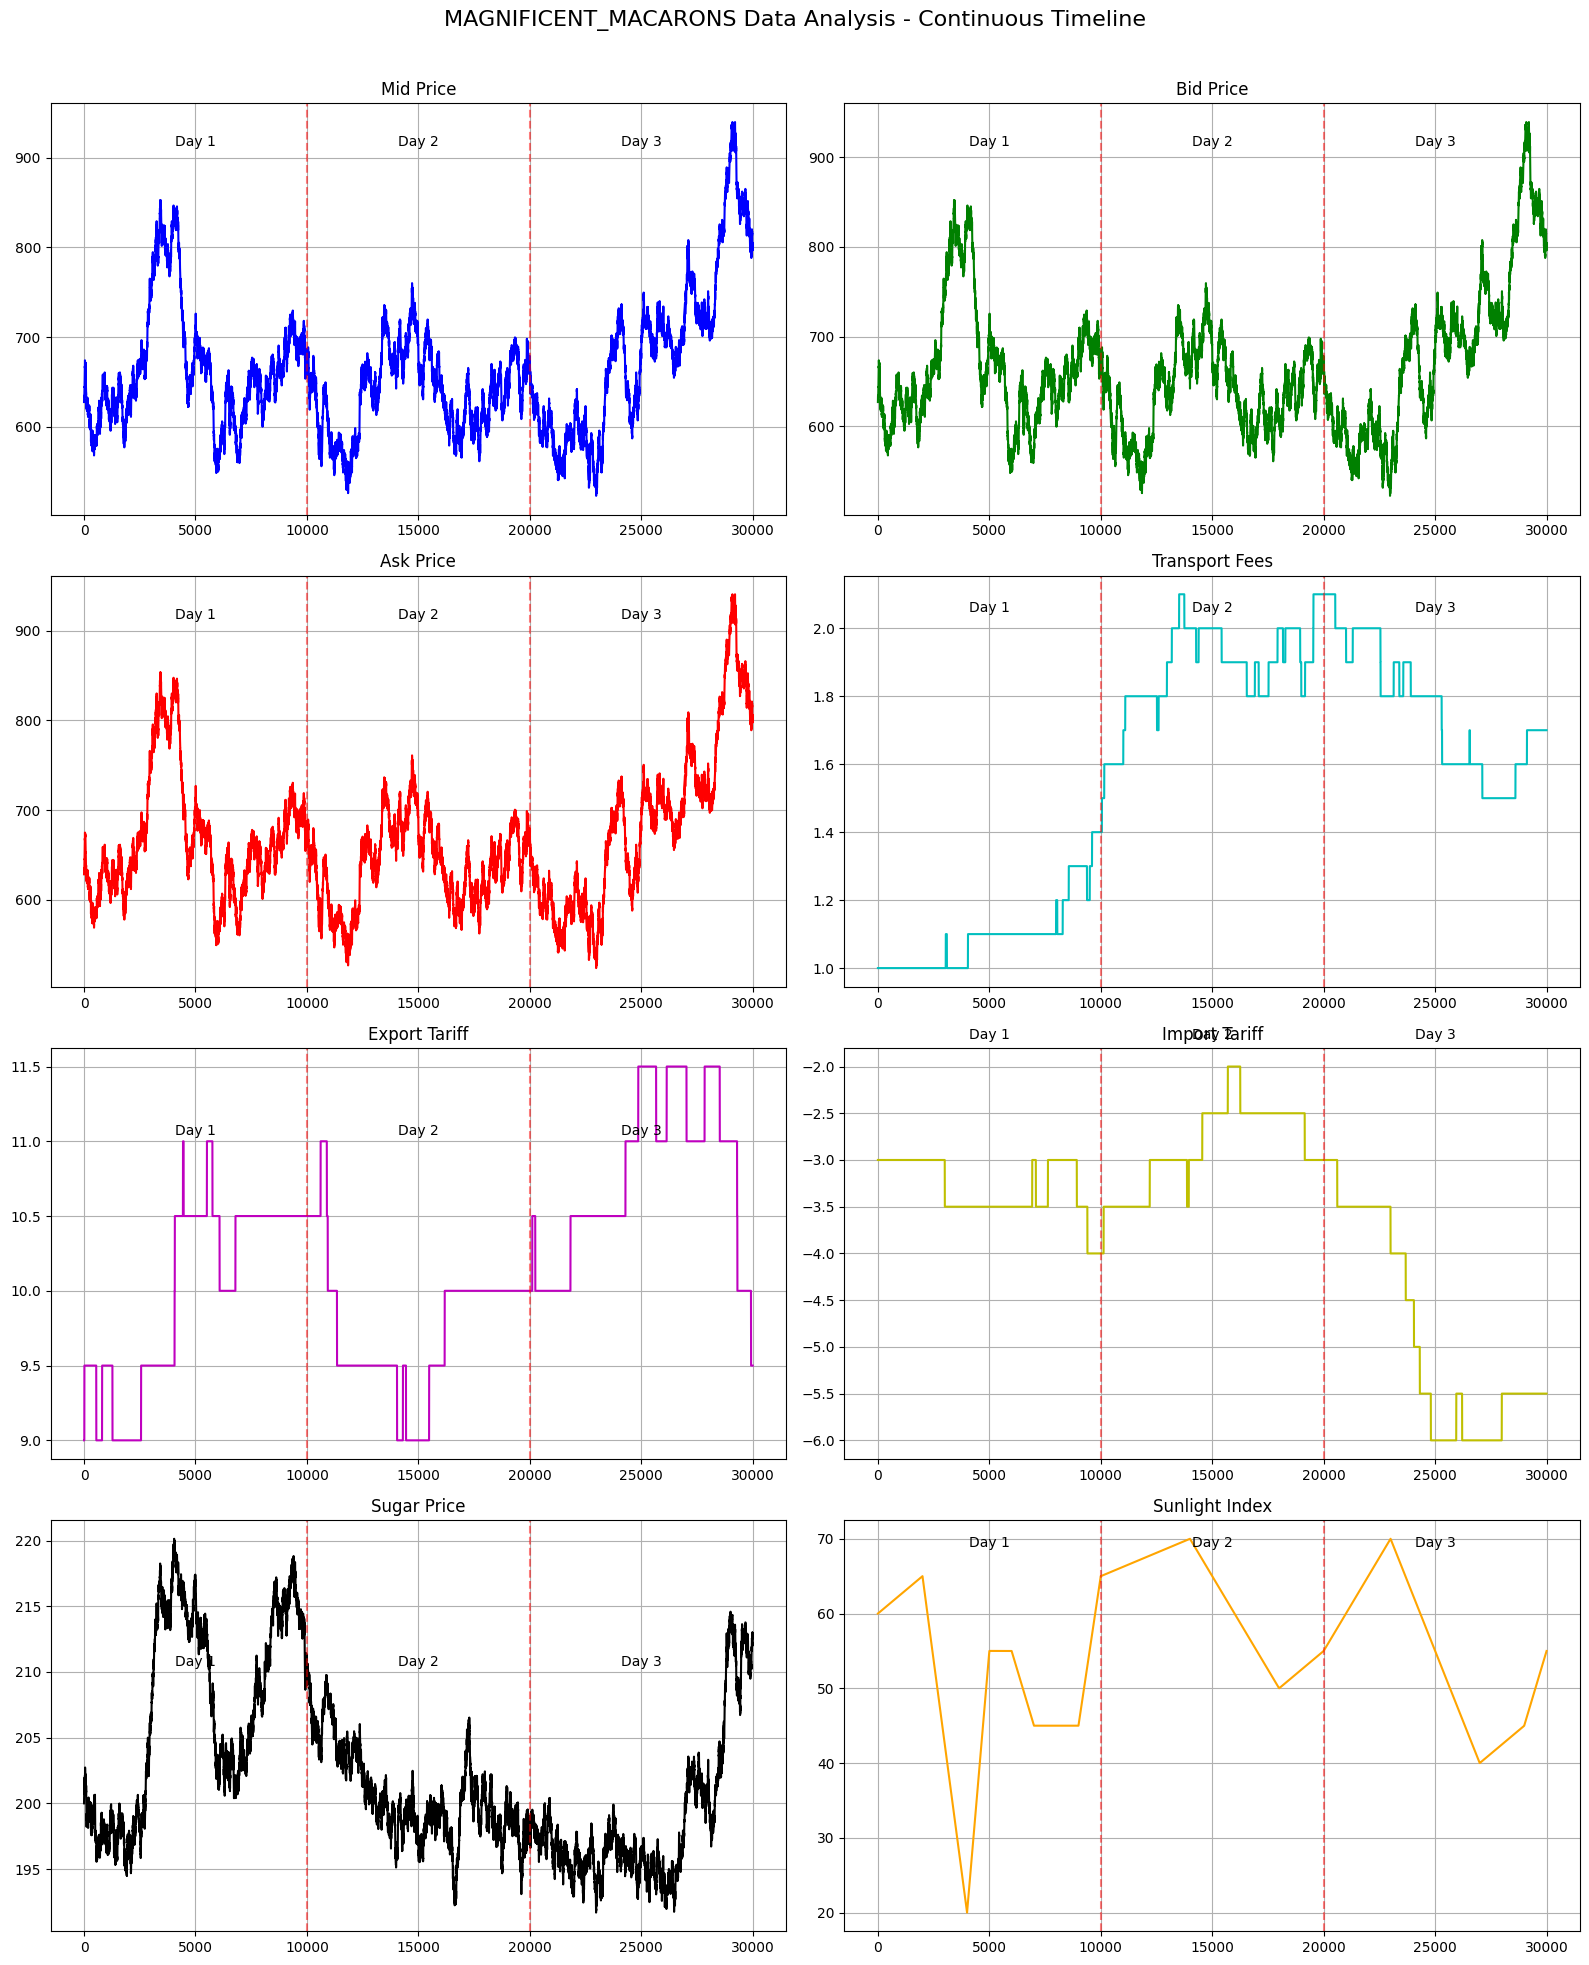

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV files correctly
data_1 = pd.read_csv('observations_round_4_day_1.csv', header=0)
data_2 = pd.read_csv('observations_round_4_day_2.csv', header=0)
data_3 = pd.read_csv('observations_round_4_day_3.csv', header=0)

# Find the length of each day's data
len_day1 = len(data_1)
len_day2 = len(data_2)

# Create a new continuous index for each day
data_1['continuous_index'] = range(0, len_day1)
data_2['continuous_index'] = range(len_day1, len_day1 + len_day2)
data_3['continuous_index'] = range(len_day1 + len_day2, len_day1 + len_day2 + len(data_3))

# Concatenate all three days of data
data_all = pd.concat([data_1, data_2, data_3]).reset_index(drop=True)

# Calculate the mid price
data_all['midPrice'] = (data_all['bidPrice'] + data_all['askPrice']) / 2

# Create figure with multiple subplots to show all variables
fig, axs = plt.subplots(4, 2, figsize=(16, 20))
fig.suptitle('MAGNIFICENT_MACARONS Data Analysis - Continuous Timeline', fontsize=16)

# Plot Mid Price
axs[0, 0].plot(data_all['continuous_index'], data_all['midPrice'], 'b-')
axs[0, 0].set_title('Mid Price')
axs[0, 0].grid(True)

# Plot Bid Price
axs[0, 1].plot(data_all['continuous_index'], data_all['bidPrice'], 'g-')
axs[0, 1].set_title('Bid Price')
axs[0, 1].grid(True)

# Plot Ask Price
axs[1, 0].plot(data_all['continuous_index'], data_all['askPrice'], 'r-')
axs[1, 0].set_title('Ask Price')
axs[1, 0].grid(True)

# Plot Transport Fees
axs[1, 1].plot(data_all['continuous_index'], data_all['transportFees'], 'c-')
axs[1, 1].set_title('Transport Fees')
axs[1, 1].grid(True)

# Plot Export Tariff
axs[2, 0].plot(data_all['continuous_index'], data_all['exportTariff'], 'm-')
axs[2, 0].set_title('Export Tariff')
axs[2, 0].grid(True)

# Plot Import Tariff
axs[2, 1].plot(data_all['continuous_index'], data_all['importTariff'], 'y-')
axs[2, 1].set_title('Import Tariff')
axs[2, 1].grid(True)

# Plot Sugar Price
axs[3, 0].plot(data_all['continuous_index'], data_all['sugarPrice'], 'k-')
axs[3, 0].set_title('Sugar Price')
axs[3, 0].grid(True)

# Plot Sunlight Index
axs[3, 1].plot(data_all['continuous_index'], data_all['sunlightIndex'], color='orange')
axs[3, 1].set_title('Sunlight Index')
axs[3, 1].grid(True)

# Add day separators
for ax in axs.flatten():
    ax.axvline(x=len_day1, color='red', linestyle='--', alpha=0.5)
    ax.axvline(x=len_day1 + len_day2, color='red', linestyle='--', alpha=0.5)
    ax.text(len_day1/2, ax.get_ylim()[1]*0.95, 'Day 1', horizontalalignment='center')
    ax.text(len_day1 + len_day2/2, ax.get_ylim()[1]*0.95, 'Day 2', horizontalalignment='center')
    ax.text(len_day1 + len_day2 + len(data_3)/2, ax.get_ylim()[1]*0.95, 'Day 3', horizontalalignment='center')

# Adjust layout and save
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('macarons_all_variables_continuous.png')
plt.show()

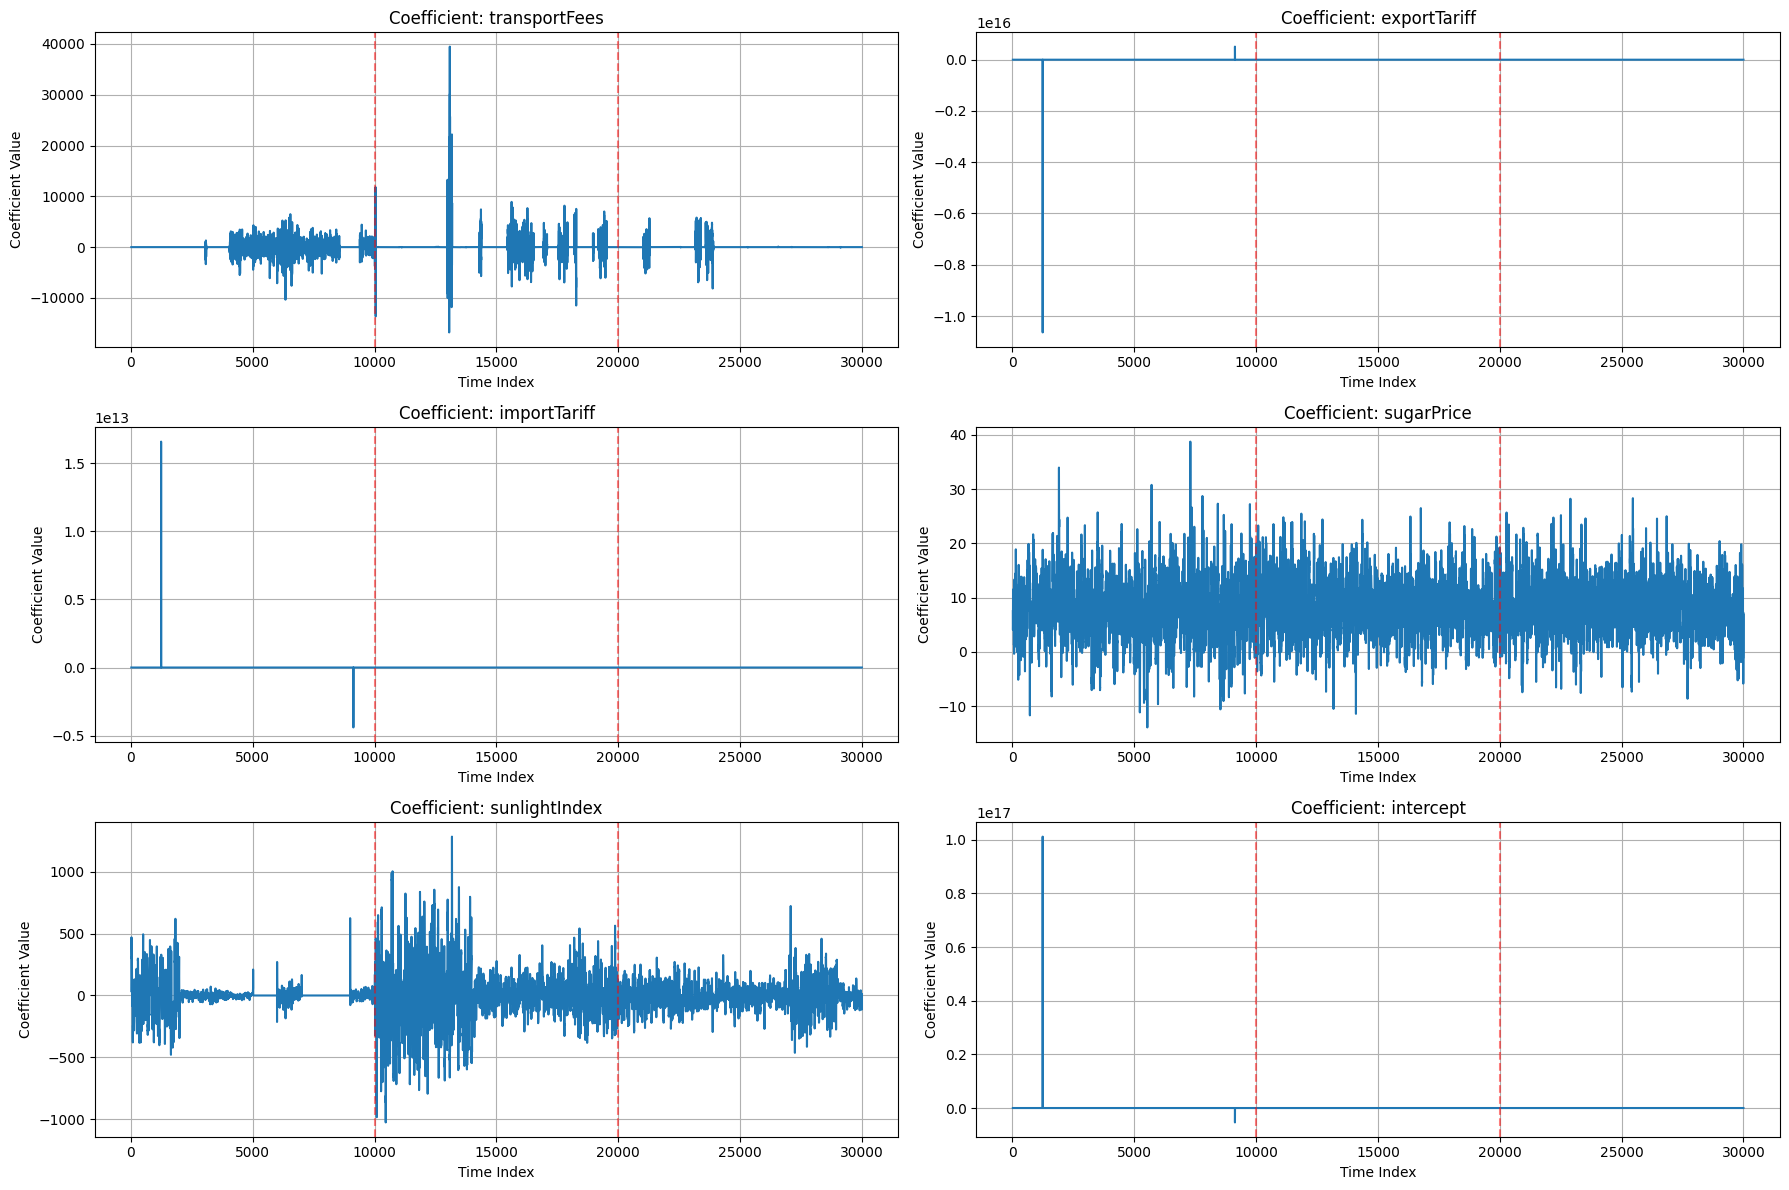

Mean coefficient values:
transportFees: 32.170992
exportTariff: -337887664071.968872
importTariff: 406624766.708673
sugarPrice: 8.132095
sunlightIndex: 1.315423
intercept: 3194060183007.596680


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
# Define the window size
window_size = 20

# Prepare to store the coefficients
feature_names = ['transportFees', 'exportTariff', 'importTariff', 'sugarPrice', 'sunlightIndex']
coefficient_names = feature_names + ['intercept']
coefficients = pd.DataFrame(index=range(len(data_all) - window_size + 1), columns=coefficient_names)

# Perform rolling regression
for i in range(len(data_all) - window_size + 1):
    # Get the window data
    window_data = data_all.iloc[i:i+window_size]
    
    # Prepare X and y
    X = window_data[feature_names]
    y = window_data['midPrice']
    
    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Store the coefficients
    for j, feature in enumerate(feature_names):
        coefficients.loc[i, feature] = model.coef_[j]
    coefficients.loc[i, 'intercept'] = model.intercept_

# Plot the coefficients
plt.figure(figsize=(18, 12))

for i, coef in enumerate(coefficient_names):
    plt.subplot(3, 2, i+1)
    plt.plot(range(window_size-1, len(data_all)), coefficients[coef])
    plt.title(f'Coefficient: {coef}')
    plt.xlabel('Time Index')
    plt.ylabel('Coefficient Value')
    plt.grid(True)
    
    # Add day separators
    plt.axvline(x=len_day1, color='red', linestyle='--', alpha=0.5)
    plt.axvline(x=len_day1 + len_day2, color='red', linestyle='--', alpha=0.5)
    
plt.tight_layout()
plt.savefig('rolling_regression_coefficients.png')
plt.show()

# Calculate and print mean coefficient values
mean_coefficients = coefficients.mean()
print("Mean coefficient values:")
for coef in coefficient_names:
    print(f"{coef}: {mean_coefficients[coef]:.6f}")